# Hands-On with Real Data: Autoencoders and Generative Adversarial Network (Vanila Encoder Version)


## I. Objectives
- Implement and train Vanilla Autoencoder, Variational Autoencoder (VAE), and Generative Adversarial Network
(GAN) models.
- Preprocess and explore MNIST, Fashion-MNIST, and a combined dataset (MNIST + Fashion-MNIST).
- Generate synthetic images using each trained model.
- Compare the quality and characteristics of generated images across datasets and models.
- Analyze the impact of training on single vs. combined datasets.
- Use visualization techniques to interpret results

In [24]:
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import numpy as np

## II. Implementation

- MNIST: Handwritten digits (0–9), 28×28 pixels, 60,000 training and 10,000 test images
- Fashion-MNIST: Fashion item images (10 classes), 28×28 pixels, 60,000 training and 10,000 test
- Combined Dataset: Combined dataset by concatenating the MNIST and Fashion-MNIST
sets

In [25]:
(x_train_mnist, y_train_mnist), (x_test_mnist, y_test_mnist) = tf.keras.datasets.mnist.load_data()

(x_train_fmnist, y_train_fmnist), (x_test_fmnist, y_test_fmnist) = tf.keras.datasets.fashion_mnist.load_data()

### A, Split the Train and Validation Data

In [26]:
x_train_mnist, x_val_mnist, y_train_mnist, y_val_mnist = train_test_split(
    x_train_mnist, y_train_mnist, test_size=0.3, random_state=42
)

x_train_fmnist, x_val_fmnist, y_train_fmnist, y_val_fmnist = train_test_split(
    x_train_fmnist, y_train_fmnist, test_size=0.3, random_state=42
)

### B, Combine into 1

In [27]:
x_train_combined = np.concatenate([x_train_mnist, x_train_fmnist], axis=0)
y_train_combined = np.concatenate([y_train_mnist, y_train_fmnist], axis=0)

x_val_combined = np.concatenate([x_val_mnist, x_val_fmnist], axis=0)
y_val_combined = np.concatenate([y_val_mnist, y_val_fmnist], axis=0)

x_test_combined = np.concatenate([x_test_mnist, x_test_fmnist], axis=0)
y_test_combined = np.concatenate([y_test_mnist, y_test_fmnist], axis=0)

### C, Explore the datasets using visualization techniques

In [28]:
uniques_mnist = np.unique(y_train_mnist)
list_lables_mnist = ["0", "1", "2", "3", "4", "5", "6", "7", "8", "9"]
dict_labels_mnist = {i: list_lables_mnist[i] for i in range(len(list_lables_mnist))}
dict_labels_mnist

{0: '0',
 1: '1',
 2: '2',
 3: '3',
 4: '4',
 5: '5',
 6: '6',
 7: '7',
 8: '8',
 9: '9'}

In [29]:
uniques_fminst = np.unique(y_train_fmnist)
list_lables_fminst = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]
dict_labels_fminst = {i: list_lables_fminst[i] for i in range(len(list_lables_fminst))}
dict_labels_fminst

{0: 'T-shirt/top',
 1: 'Trouser',
 2: 'Pullover',
 3: 'Dress',
 4: 'Coat',
 5: 'Sandal',
 6: 'Shirt',
 7: 'Sneaker',
 8: 'Bag',
 9: 'Ankle boot'}

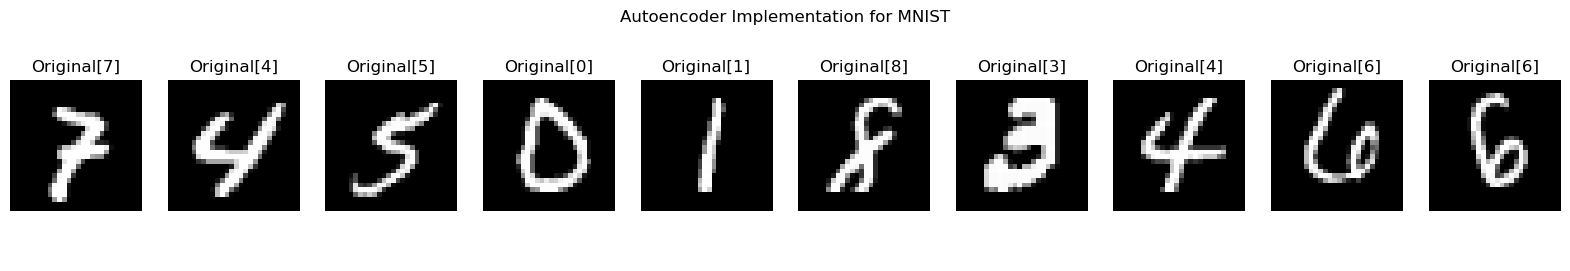

In [30]:
def plot_images_single_dataset(original_images, class_lables, num_images=10, dataset_name='MNIST'):
    plt.figure(figsize=(20, 3))
    plt.title(f"Autoencoder Implementation for {dataset_name}")
    plt.axis('off')
    for i in range(num_images):
        ax = plt.subplot(1, num_images, i + 1)
        plt.imshow(original_images[i].reshape(28, 28), cmap='gray')
        plt.title(f"Original[{class_lables[i]}]")
        plt.axis('off')

plot_images_single_dataset(x_train_combined, y_train_combined)

### C, Reshape the dataset

#### MNIST

In [31]:
x_train_mnist_reshape = x_train_mnist.reshape(-1, x_train_mnist.shape[1] * x_train_mnist.shape[2])
x_val_mnist_reshape = x_val_mnist.reshape(-1, x_val_mnist.shape[1] * x_val_mnist.shape[2])
x_test_mnist_reshape = x_test_mnist.reshape(-1, x_test_mnist.shape[1] * x_test_mnist.shape[2])

#### Fashion-MNIST

In [32]:
x_train_fmnist_reshape = x_train_fmnist.reshape(-1, x_train_fmnist.shape[1] * x_train_fmnist.shape[2])
x_val_fmnist_reshape = x_val_fmnist.reshape(-1, x_val_fmnist.shape[1] * x_val_fmnist.shape[2])
x_test_fmnist_reshape = x_test_fmnist.reshape(-1, x_test_fmnist.shape[1] * x_test_fmnist.shape[2])

#### Combined Dataset

In [33]:
x_train_combined_reshape = x_train_combined.reshape(-1, x_train_combined.shape[1] * x_train_combined.shape[2])
x_val_combined_reshape = x_val_combined.reshape(-1, x_val_combined.shape[1] * x_val_combined.shape[2])
x_test_combined_reshape = x_test_combined.reshape(-1, x_test_combined.shape[1] * x_test_combined.shape[2])

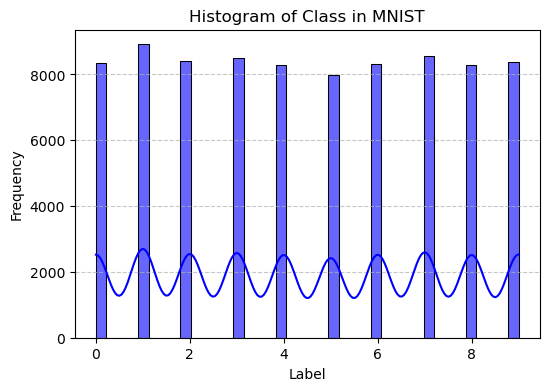

In [34]:
def plot_histogram(column_data, default_bin=10, dataset="MNIST"):
    iqr = np.percentile(column_data, 75) - np.percentile(column_data, 25)
    bin_width_fd = 2 * iqr / (len(column_data) ** (1 / 3))
    if bin_width_fd > 0:
        n_bins_fd = int(np.ceil((column_data.max() - column_data.min()) / bin_width_fd))
    else:
        n_bins_fd = default_bin

    plt.figure(figsize=(6, 4))
    sns.histplot(column_data, bins=n_bins_fd, kde=True, color="blue", alpha=0.6)
    plt.title(f'Histogram of Class in {dataset}')
    plt.xlabel('Label')
    plt.ylabel('Frequency')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

plot_histogram(y_train_combined)

### D, Normalize Data

In [35]:
x_train_mnist_normalized = x_train_mnist_reshape / 255.0
x_val_mnist_normalized = x_val_mnist_reshape / 255.0
x_test_mnist_normalized = x_test_mnist_reshape / 255.0

x_train_fmnist_normalized = x_train_fmnist_reshape / 255.0
x_val_fmnist_normalized = x_val_fmnist_reshape / 255.0
x_test_fmnist_normalized = x_test_fmnist_reshape / 255.0

x_train_combined_normalized = x_train_combined_reshape / 255.0
x_val_combined_normalized = x_val_combined_reshape / 255.0
x_test_combined_normalized = x_test_combined_reshape / 255.0

### E, Vanilla Encoder (For Single Dataset Version)

In [36]:
def create_vanilla_autoencoder(input_dim, latent_dim):
    encoder_inputs = layers.Input(shape=(input_dim,))
    x = layers.Dense(256, activation='relu')(encoder_inputs)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(64, activation='relu')(x)
    z = layers.Dense(latent_dim, activation='relu')(x)
    encoder = Model(encoder_inputs, z, name='encoder')

    decoder_inputs = layers.Input(shape=(latent_dim,))
    x = layers.Dense(64, activation='relu')(decoder_inputs)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(256, activation='relu')(x)
    outputs = layers.Dense(input_dim, activation='sigmoid')(x)
    decoder = Model(decoder_inputs, outputs, name='decoder')

    autoencoder_outputs = decoder(encoder(encoder_inputs))
    autoencoder = Model(encoder_inputs, autoencoder_outputs, name='autoencoder')

    autoencoder.compile(optimizer='adam', loss='mean_squared_error')
    
    return autoencoder, encoder, decoder

In [37]:
def plot_reconstructions_images_single_dataset(original_images, reconstructed_images, num_images=10, dataset_name='MNIST'):
    plt.figure(figsize=(20, 6))
    plt.title(f"Autoencoder Implementation for {dataset_name}")
    plt.axis('off')
    for i in range(num_images):
        ax = plt.subplot(2, num_images, i + 1)
        plt.imshow(original_images[i].reshape(28, 28), cmap='gray')
        plt.title(f"Original[{i}]")
        plt.axis('off')
        
        ax = plt.subplot(2, num_images, i + num_images + 1)
        plt.imshow(reconstructed_images[i].reshape(28, 28), cmap='gray')
        plt.title(f"Reconstructed[{i}]")
        plt.axis('off')
    plt.show()

#### MNIST

Epoch 1/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.1031 - val_loss: 0.0500
Epoch 2/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0441 - val_loss: 0.0329
Epoch 3/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0303 - val_loss: 0.0258
Epoch 4/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0246 - val_loss: 0.0231
Epoch 5/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0219 - val_loss: 0.0208
Epoch 6/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0199 - val_loss: 0.0198
Epoch 7/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0183 - val_loss: 0.0184
Epoch 8/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0172 - val_loss: 0.0176
Epoch 9/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0164 - val_loss: 0.0163
Epoch 10/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0157 - val_loss: 0.0159
Epoch 11/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0150 - val_loss: 0.0157
Epoch 12/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step

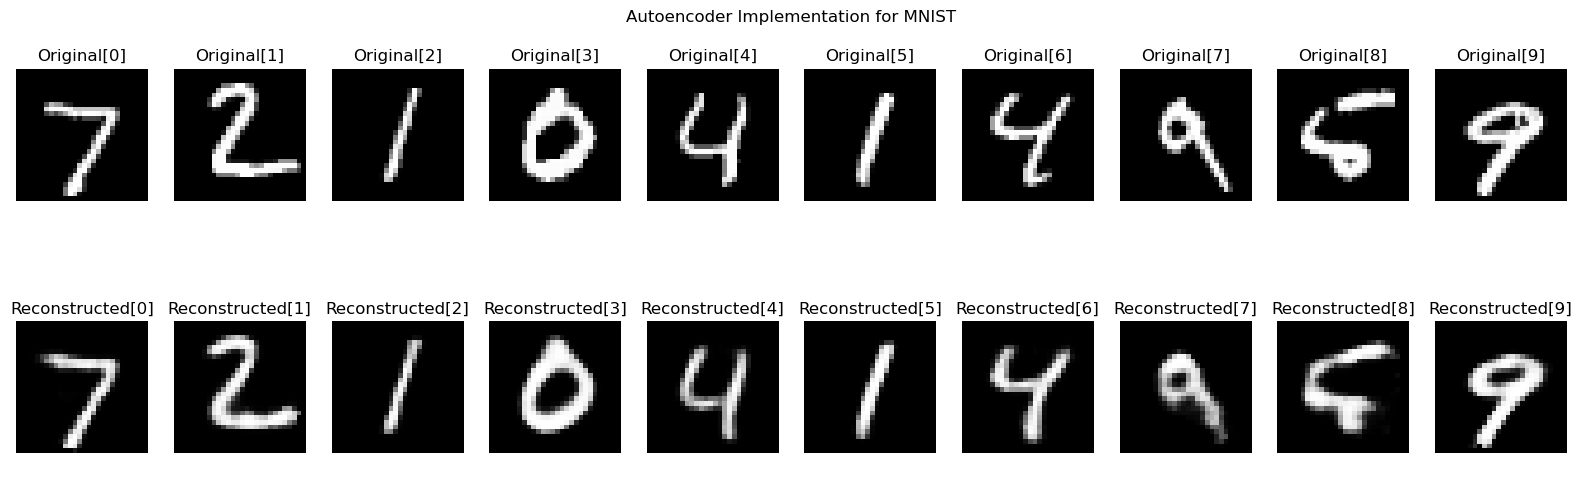

In [38]:
def autoencoder_mnist_implementation(x_train_mnist_normalized, x_val_mnist_normalized, x_test_mnist_normalized):
    input_dim = x_train_mnist_normalized.shape[1]
    latent_dim = 32

    autoencoder_mnist, encoder_mnist, decoder_mnist = create_vanilla_autoencoder(input_dim, latent_dim)

    autoencoder_mnist.fit(
        x_train_mnist_normalized,
        x_train_mnist_normalized,
        epochs=50,
        batch_size=256,
        validation_data=(x_val_mnist_normalized, x_val_mnist_normalized)
    )

    reconstructed_images = autoencoder_mnist.predict(x_test_mnist_normalized)

    mse = tf.keras.losses.MeanSquaredError()
    mse_value = mse(x_test_mnist_normalized, reconstructed_images).numpy()
    print(f"Mean Squared Error on test set: {mse_value:.6f}")

    return autoencoder_mnist, encoder_mnist, decoder_mnist, reconstructed_images

autoencoder_mnist, encoder_mnist, decoder_mnist, reconstructed_images = autoencoder_mnist_implementation(x_train_mnist_normalized, x_val_mnist_normalized, x_test_mnist_normalized)
plot_reconstructions_images_single_dataset(x_test_mnist_normalized, reconstructed_images, num_images=10, dataset_name='MNIST')

#### Fashion-MNIST

Epoch 1/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0905 - val_loss: 0.0340
Epoch 2/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0299 - val_loss: 0.0240
Epoch 3/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0228 - val_loss: 0.0227
Epoch 4/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0209 - val_loss: 0.0206
Epoch 5/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0193 - val_loss: 0.0187
Epoch 6/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0184 - val_loss: 0.0190
Epoch 7/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0175 - val_loss: 0.0191
Epoch 8/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0171 - val_loss: 0.0169
Epoch 9/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0163 - val_loss: 0.0164
Epoch 10/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0159 - val_loss: 0.0161
Epoch 11/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0155 - val_loss: 0.0156
Epoch 12/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/st

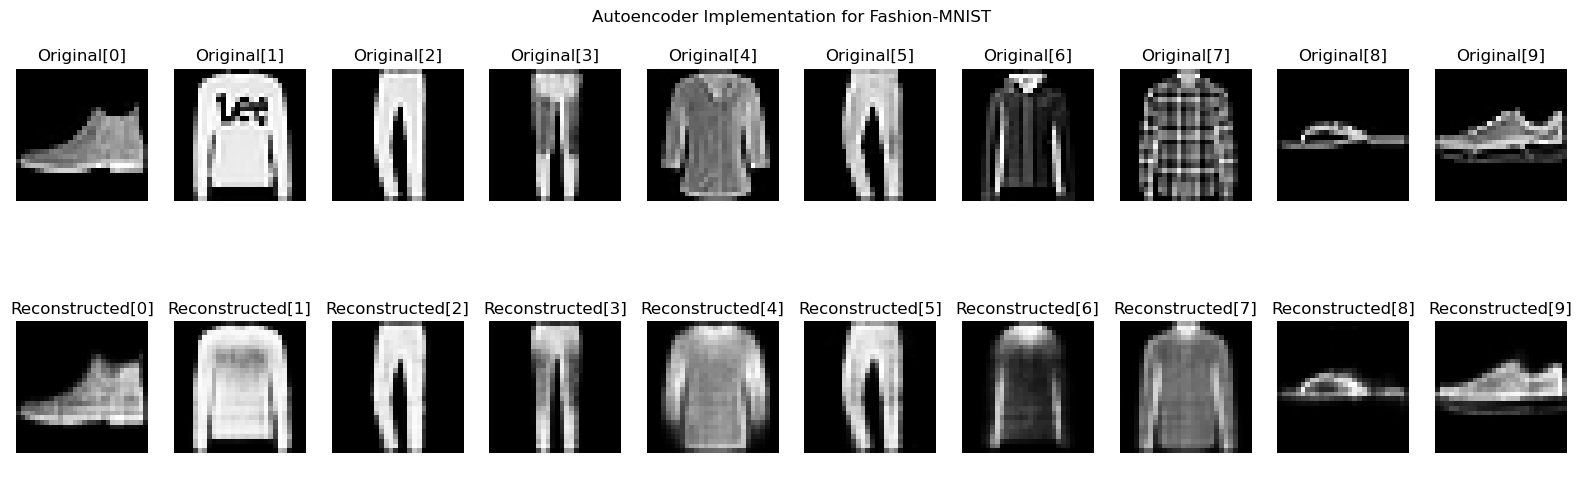

In [39]:
def autoencoder_mnist_fashion_implementation(x_train_fmnist_fashsion_normalized, x_val_fmnist_fashsion_normalized, x_test_fmnist_fashsion_normalized):
    input_dim = x_train_fmnist_fashsion_normalized.shape[1]
    latent_dim = 32

    autoencoder_mnist_fashion, encoder_mnist_fashion, decoder_mnist_fashion = create_vanilla_autoencoder(input_dim, latent_dim)

    autoencoder_mnist_fashion.fit(
        x_train_fmnist_fashsion_normalized,
        x_train_fmnist_fashsion_normalized,
        epochs=50,
        batch_size=256,
        validation_data=(x_val_fmnist_fashsion_normalized, x_val_fmnist_fashsion_normalized)
    )

    reconstructed_images_fashion = autoencoder_mnist_fashion.predict(x_test_fmnist_fashsion_normalized)

    mse = tf.keras.losses.MeanSquaredError()
    mse_value = mse(x_test_fmnist_fashsion_normalized, reconstructed_images_fashion).numpy()
    print(f"Mean Squared Error on test set: {mse_value:.6f}")

    return autoencoder_mnist_fashion, encoder_mnist_fashion, decoder_mnist_fashion, reconstructed_images_fashion

autoencoder_mnist_fashion, encoder_mnist_fashion, decoder_mnist_fashion, reconstructed_images_fashion = autoencoder_mnist_fashion_implementation(x_train_fmnist_normalized, x_val_fmnist_normalized, x_test_fmnist_normalized)
plot_reconstructions_images_single_dataset(x_test_fmnist_normalized, reconstructed_images_fashion, num_images=10, dataset_name='Fashion-MNIST')

### F, Vanilla Encoder (For Combined Dataset Version)

#### Combined Data

In [40]:
def create_vanilla_autoencoder_combined_version(input_dim, latent_dim):
    encoder_inputs = layers.Input(shape=(input_dim,))
    x = layers.Dense(512, activation='relu')(encoder_inputs)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dense(128, activation='relu')(x)
    z = layers.Dense(latent_dim, activation='relu')(x)
    encoder = Model(encoder_inputs, z, name='encoder')

    decoder_inputs = layers.Input(shape=(latent_dim,))
    x = layers.Dense(128, activation='relu')(decoder_inputs)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dense(512, activation='relu')(x)
    outputs = layers.Dense(input_dim, activation='sigmoid')(x)
    decoder = Model(decoder_inputs, outputs, name='decoder')

    autoencoder_outputs = decoder(encoder(encoder_inputs))
    autoencoder = Model(encoder_inputs, autoencoder_outputs, name='autoencoder')

    autoencoder.compile(optimizer='adam', loss='mean_squared_error')
    
    return autoencoder, encoder, decoder

In [41]:
def plot_reconstructions_images_combined_dataset(original_images, reconstructed_images, num_images=10, dataset_name='MNIST'):
    plt.figure(figsize=(20, 10))
    plt.title(f"Autoencoder Implementation for {dataset_name}")
    plt.axis('off')
    for i in range(num_images):
        ax = plt.subplot(4, num_images, i + 1)
        plt.imshow(original_images[i].reshape(28, 28), cmap='gray')
        plt.title(f"Original[{i}]")
        plt.axis('off')
        
        ax = plt.subplot(4, num_images, i + num_images + 1)
        plt.imshow(reconstructed_images[i].reshape(28, 28), cmap='gray')
        plt.title(f"Reconstructed[{i}]")
        plt.axis('off')

    for i in range(num_images):
        ax = plt.subplot(4, num_images, i + num_images * 2 + 1)
        plt.imshow(original_images[-i].reshape(28, 28), cmap='gray')
        plt.title(f"Original[{i}]")
        plt.axis('off')
        
        ax = plt.subplot(4, num_images, i + num_images * 3 + 1)
        plt.imshow(reconstructed_images[-i].reshape(28, 28), cmap='gray')
        plt.title(f"Reconstructed[{i}]")
        plt.axis('off')

    plt.show()

Epoch 1/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 0.0755 - val_loss: 0.0276
Epoch 2/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0250 - val_loss: 0.0210
Epoch 3/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0195 - val_loss: 0.0179
Epoch 4/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0169 - val_loss: 0.0161
Epoch 5/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0153 - val_loss: 0.0148
Epoch 6/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0141 - val_loss: 0.0141
Epoch 7/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0133 - val_loss: 0.0134
Epoch 8/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0127 - val_loss: 0.0134
Epoch 9/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0122 - val_loss: 0.0123
Epoch 10/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0117 - val_loss: 0.0119
Epoch 11/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0113 - val_loss: 0.0114
Epoch 12/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 

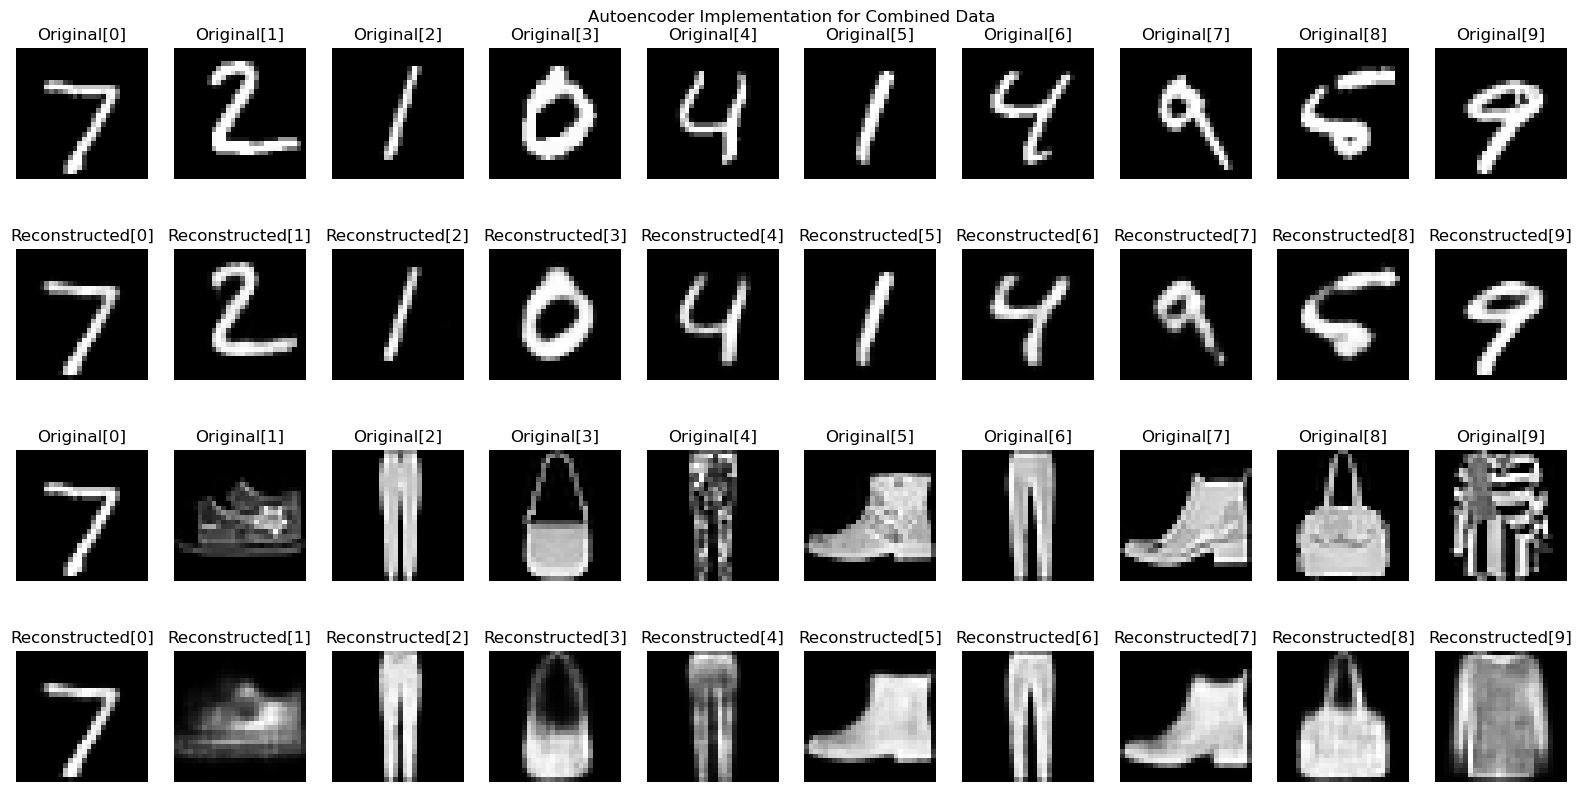

In [42]:
def autoencoder_mnist_combined_implementation(x_train_combined_normalized, x_val_combined_normalized, x_test_combined_normalized):
    input_dim = x_train_combined_normalized.shape[1]
    latent_dim = 32

    autoencoder_mnist_combined, encoder_mnist_combined, decoder_mnist_combined = create_vanilla_autoencoder_combined_version(input_dim, latent_dim)

    autoencoder_mnist_combined.fit(
        x_train_combined_normalized,
        x_train_combined_normalized,
        epochs=50,
        batch_size=256,
        validation_data=(x_val_combined_normalized, x_val_combined_normalized)
    )

    reconstructed_images_combined = autoencoder_mnist_combined.predict(x_test_combined_normalized)

    mse = tf.keras.losses.MeanSquaredError()
    mse_value = mse(x_test_combined_normalized, reconstructed_images_combined).numpy()
    print(f"Mean Squared Error on test set: {mse_value:.6f}")

    return autoencoder_mnist_combined, encoder_mnist_combined, decoder_mnist_combined, reconstructed_images_combined

autoencoder_mnist_combined, encoder_mnist_combined, decoder_mnist_combined, reconstructed_images_combined = autoencoder_mnist_combined_implementation(x_train_combined_normalized, x_val_combined_normalized, x_test_combined_normalized)
plot_reconstructions_images_combined_dataset(x_test_combined_normalized, reconstructed_images_combined, num_images=10, dataset_name='Combined Data')

### G, VAE

In [43]:
x_train_mnist_normalized.shape

(42000, 784)

In [44]:
class Sampling(layers.Layer):
    """Uses (z_mean, z_log_var) to sample z, the vector encoding a digit."""

    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.seed_generator = tf.keras.random.SeedGenerator(1337)

    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.keras.ops.shape(z_mean)[0]
        dim = tf.keras.ops.shape(z_mean)[1]
        epsilon = tf.keras.keras.random.normal(shape=(batch, dim), seed=self.seed_generator)
        return z_mean + tf.keras.ops.exp(0.5 * z_log_var) * epsilon
    

In [48]:
def create_vae_autoencoder(input_dim, latent_dim):
    encoder_inputs = layers.Input(shape=(input_dim,))
    x = layers.Dense(256, activation='relu')(encoder_inputs)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(64, activation='relu')(x)

    z_mean = layers.Dense(latent_dim, name="z_mean")(x)
    z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
    z = Sampling()([z_mean, z_log_var])

    encoder_vae = Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

    decoder_inputs = layers.Input(shape=(latent_dim,))
    x = layers.Dense(64, activation='relu')(decoder_inputs)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(256, activation='relu')(x)
    outputs = layers.Dense(input_dim, activation='sigmoid')(x)
    decoder_vae = Model(decoder_inputs, outputs, name='decoder')

    autoencoder_outputs = decoder_vae(encoder_vae(encoder_inputs))
    autoencoder_vae = Model(encoder_inputs, autoencoder_outputs, name='autoencoder')

    autoencoder_vae.compile(optimizer='adam', loss='mean_squared_error')
    
    return autoencoder_vae, encoder_vae, decoder_vae

latent_dim = 32
autoencoder_vae, encoder_vae, decoder_vae = create_vae_autoencoder(x_train_mnist_normalized.shape[1], latent_dim)

AttributeError: Exception encountered when calling Sampling.call().

[1mCould not automatically infer the output shape / dtype of 'sampling' (of type Sampling). Either the `Sampling.call()` method is incorrect, or you need to implement the `Sampling.compute_output_spec() / compute_output_shape()` method. Error encountered:

module 'tensorflow.keras' has no attribute 'keras'[0m

Arguments received by Sampling.call():
  • args=(['<KerasTensor shape=(None, 32), dtype=float32, sparse=False, ragged=False, name=keras_tensor_40>', '<KerasTensor shape=(None, 32), dtype=float32, sparse=False, ragged=False, name=keras_tensor_41>'],)
  • kwargs=<class 'inspect._empty'>

In [19]:
class VAE(tf.keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = tf.keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(
            name="reconstruction_loss"
        )
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.keras.ops.mean(
                tf.keras.ops.sum(
                    tf.keras.losses.binary_crossentropy(data, reconstruction),
                    axis=(1, 2),
                )
            )
            kl_loss = -0.5 * (1 + z_log_var - tf.keras.ops.square(z_mean) - tf.keras.ops.exp(z_log_var))
            kl_loss = tf.keras.ops.mean(tf.keras.ops.sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

In [20]:
vae = VAE(encoder_vae, decoder_vae)
vae.compile(optimizer=tf.keras.optimizers.Adam())
vae.fit(x_train_mnist_normalized, epochs=30, batch_size=128)

NameError: name 'encoder_vae' is not defined